In [41]:
import elapid
import rasterio as rio
import pandas as pd
import geopandas as gpd
from src.sample_raster_data import get_rasters_list
import matplotlib.pyplot as plt

In [42]:
año = 2018
month = '01'
output_raster = f'src/models/predicted_raster_{month}.tif'
rasters, labels = get_rasters_list(year=año, month=month)
print(rasters)

['src/data/resampled_data/2018/01/eastward_wind.tif', 'src/data/resampled_data/2018/01/northward_wind.tif', 'src/data/resampled_data/2018/01/sst_resampled.tif', 'src/data/resampled_data/2018/01/chlor_a_resampled.tif']


In [43]:
# Load the model
model_name = 'src/models/maxent_model_enero.pkl'
#model_name = 'src/models/maxent_model_febrero.pkl'
model = elapid.load_object(model_name)

In [44]:
elapid.apply_model_to_rasters(model, rasters, output_raster, quiet=True)

(204, 276)


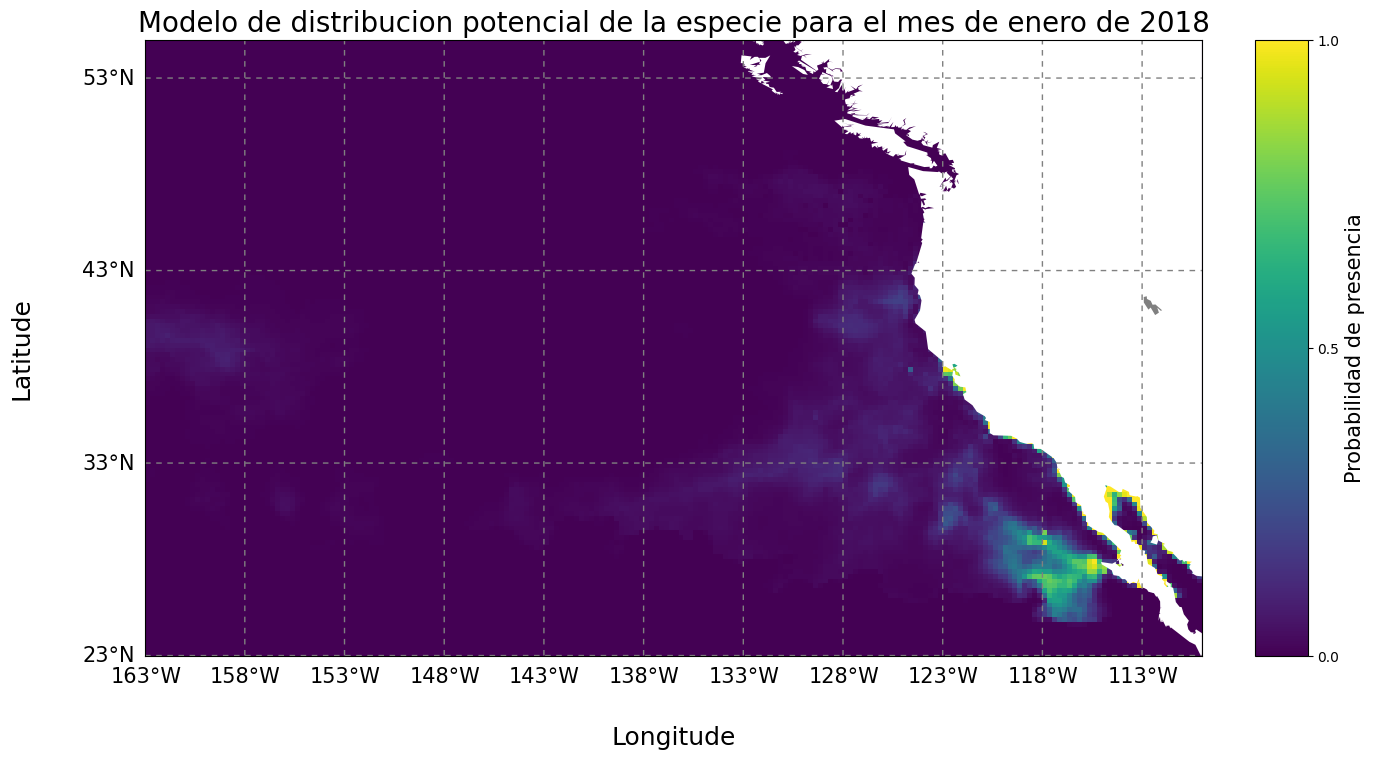

In [45]:
# Mapa de la zona de estudio
import matplotlib.pyplot as plt
from shapely import wkt
import geopandas as gpd
import xarray as xr
import rioxarray as rxr
from mpl_toolkits.basemap import Basemap
import numpy as np

pred = rxr.open_rasterio(output_raster)

pred = pred.squeeze()
print(pred.shape)

# Define bounding box
min_lat, max_lat = 23, 55
min_lon, max_lon = -163, -110
zoom_min_lat, zoom_max_lat = 30.5, 30.9
zoom_min_lon, zoom_max_lon = -123, -122.6

# Plot the data
fig, axs = plt.subplots(1, 1, figsize=(15,8))
inset_lims = [0.68, 0.5, 0.4, 0.4]

# Plot sea surface temperature
m = Basemap(projection='cyl', resolution='l', ax=axs, llcrnrlat=min_lat, urcrnrlat=max_lat, llcrnrlon=min_lon, urcrnrlon=max_lon)
pred = pred.squeeze()
x, y = pred.x, pred.y
cs = m.pcolormesh(x, y, pred, cmap='viridis', latlon=True, vmin=0, vmax=1)
m.fillcontinents(color='white', lake_color='gray') 
#m.drawcoastlines(color='gray')
#m.drawcountries(color='gray')
m.drawmeridians(np.arange(min_lon, max_lon, 5), labels=[0, 0, 0, 1], color='gray', fontsize=15, dashes=[4, 4])
m.drawparallels(np.arange(min_lat, max_lat, 10), labels=[1, 0, 0, 0], color='gray', fontsize=15, dashes=[4, 4])
cbar = m.colorbar(cs, location='right', pad="5%", size="5%", ticks=[0, 0.5, 1])
cbar.set_label('Probabilidad de presencia', fontsize=15)
axs.set_title('Modelo de distribucion potencial de la especie para el mes de enero de 2018', fontsize=20)
axs.set_xlabel('Longitude', fontsize=18, labelpad=50)
axs.set_ylabel('Latitude', fontsize=18, labelpad=80)
axs.set_aspect('auto')
axs.set_xlim(min_lon, max_lon)
axs.set_ylim(min_lat, max_lat)
axs.grid()